In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time
from sklearn.model_selection import train_test_split 

from src.data_processing import clean_text
from src.bag_of_words import NumpyBagOfWords
from src.hyperopt import build_grid

from src.models_numpy.dnn.neuralnet import NeuralNetwork
from src.models_numpy.dnn.layers import DenseLayer
from src.models_numpy.dnn.activation import ReLUActivation, SoftmaxActivation
from src.models_numpy.dnn.losses import CategoricalCrossEntropy
from src.models_numpy.dnn.optimizer import SGD

df = pd.read_csv("../data/processed/dataset_kaggle_daigt_processed.csv", sep=";")

label_map = {label: i for i, label in enumerate(df['Label'].unique())}
df['label_id'] = df['Label'].map(label_map)

df['text_clean'] = df['Text'].apply(clean_text)

X_train, X_val, y_train, y_val = train_test_split(
    df['text_clean'], df['label_id'], test_size=0.2, random_state=42, stratify=df['label_id']
)

param_grid_dnn = {
    'max_words': [2500, 3000],
    'hidden_neurons': [64, 128, 164],
    'learning_rate': [0.05, 0.1],
    'epochs': [150, 200]
}

resultados_dnn = []

print("=== A Iniciar Grid Search: DNN ===")
for params in build_grid(param_grid_dnn):
    print(f"\nA testar: {params}")
    inicio = time.time()

    num_classes = len(label_map)
    y_train_oh = np.eye(num_classes)[y_train.values]
    y_val_oh = np.eye(num_classes)[y_val.values]
    
    bow = NumpyBagOfWords(max_words=params['max_words'])
    X_tr = bow.fit_transform(X_train)
    X_te = bow.transform(X_val)
    
    model = NeuralNetwork()
    model.add(DenseLayer(input_size=params['max_words'], output_size=params['hidden_neurons']))
    model.add(ReLUActivation())
    model.add(DenseLayer(input_size=params['hidden_neurons'], output_size=5))
    model.add(SoftmaxActivation())
    
    model.compile(loss_func=CategoricalCrossEntropy(), optimizer=SGD(learning_rate=params['learning_rate']))
    
    history = model.fit(X_tr, y_train_oh, epochs=params['epochs'], val_data=(X_te, y_val_oh))
    
    val_acc_final = history['val_acc'][-1]
    val_loss_final = history['val_loss'][-1]
    tempo_gasto = time.time() - inicio
    
    resultados_dnn.append({
        'Max Words': params['max_words'],
        'Hidden Neurons': params['hidden_neurons'],
        'Learning Rate': params['learning_rate'],
        'Val Accuracy': val_acc_final,
        'Val Loss': val_loss_final,
        'Tempo (s)': round(tempo_gasto, 1)
    })
    print(f" -> Val Acc: {val_acc_final:.4f} | Tempo: {tempo_gasto:.1f}s")

df_grid_dnn = pd.DataFrame(resultados_dnn).sort_values(by='Val Accuracy', ascending=False)
display(df_grid_dnn)

=== A Iniciar Grid Search: DNN ===

A testar: {'max_words': 3000, 'hidden_neurons': 64, 'learning_rate': 0.05, 'epochs': 150}
Epoch 10/150 | Loss: 1.4919 Acc: 0.5423 | Val Loss: 1.4687 Val Acc: 0.5579
Epoch 20/150 | Loss: 1.2112 Acc: 0.6811 | Val Loss: 1.1900 Val Acc: 0.6840
Epoch 30/150 | Loss: 0.9306 Acc: 0.7422 | Val Loss: 0.9349 Val Acc: 0.7425
Epoch 40/150 | Loss: 0.7409 Acc: 0.7770 | Val Loss: 0.7706 Val Acc: 0.7646
Epoch 50/150 | Loss: 0.6116 Acc: 0.8157 | Val Loss: 0.6665 Val Acc: 0.7893
Epoch 60/150 | Loss: 0.5175 Acc: 0.8453 | Val Loss: 0.5933 Val Acc: 0.8127
Epoch 70/150 | Loss: 0.4485 Acc: 0.8683 | Val Loss: 0.5418 Val Acc: 0.8231
Epoch 80/150 | Loss: 0.3950 Acc: 0.8859 | Val Loss: 0.5033 Val Acc: 0.8336
Epoch 90/150 | Loss: 0.3517 Acc: 0.8963 | Val Loss: 0.4733 Val Acc: 0.8375
Epoch 100/150 | Loss: 0.3156 Acc: 0.9067 | Val Loss: 0.4500 Val Acc: 0.8492
Epoch 110/150 | Loss: 0.2847 Acc: 0.9174 | Val Loss: 0.4312 Val Acc: 0.8570
Epoch 120/150 | Loss: 0.2580 Acc: 0.9288 | Val 

,Max Words,Hidden Neurons,Learning Rate,Val Accuracy,Val Loss,Tempo (s)
9,3000,164,0.05,0.886866,0.369668,18.1
5,3000,128,0.05,0.885566,0.373473,14.7
7,3000,128,0.10,0.885566,0.373599,15.4
6,3000,128,0.10,0.884265,0.362264,10.4
11,3000,164,0.10,0.882965,0.374598,18.5
10,3000,164,0.10,0.880364,0.365407,12.6
2,3000,64,0.10,0.880364,0.371740,8.0
1,3000,64,0.05,0.877763,0.367153,12.0
0,3000,64,0.05,0.875163,0.386570,10.3
3,3000,64,0.10,0.872562,0.389251,10.2


A treinar o Modelo DNN Final...
Epoch 10/200 | Loss: 1.3701 Acc: 0.6417 | Val Loss: 1.3360 Val Acc: 0.6268
Epoch 20/200 | Loss: 0.9281 Acc: 0.7308 | Val Loss: 0.9264 Val Acc: 0.7126
Epoch 30/200 | Loss: 0.6541 Acc: 0.7864 | Val Loss: 0.7062 Val Acc: 0.7633
Epoch 40/200 | Loss: 0.4884 Acc: 0.8397 | Val Loss: 0.5812 Val Acc: 0.7984
Epoch 50/200 | Loss: 0.3838 Acc: 0.8784 | Val Loss: 0.5039 Val Acc: 0.8309
Epoch 60/200 | Loss: 0.3109 Acc: 0.9005 | Val Loss: 0.4509 Val Acc: 0.8492
Epoch 70/200 | Loss: 0.2566 Acc: 0.9230 | Val Loss: 0.4179 Val Acc: 0.8531
Epoch 80/200 | Loss: 0.2141 Acc: 0.9376 | Val Loss: 0.3963 Val Acc: 0.8635
Epoch 90/200 | Loss: 0.1802 Acc: 0.9555 | Val Loss: 0.3822 Val Acc: 0.8726
Epoch 100/200 | Loss: 0.1530 Acc: 0.9665 | Val Loss: 0.3733 Val Acc: 0.8791
Epoch 110/200 | Loss: 0.1308 Acc: 0.9753 | Val Loss: 0.3679 Val Acc: 0.8804
Epoch 120/200 | Loss: 0.1128 Acc: 0.9837 | Val Loss: 0.3650 Val Acc: 0.8817
Epoch 130/200 | Loss: 0.0981 Acc: 0.9870 | Val Loss: 0.3638 Val A

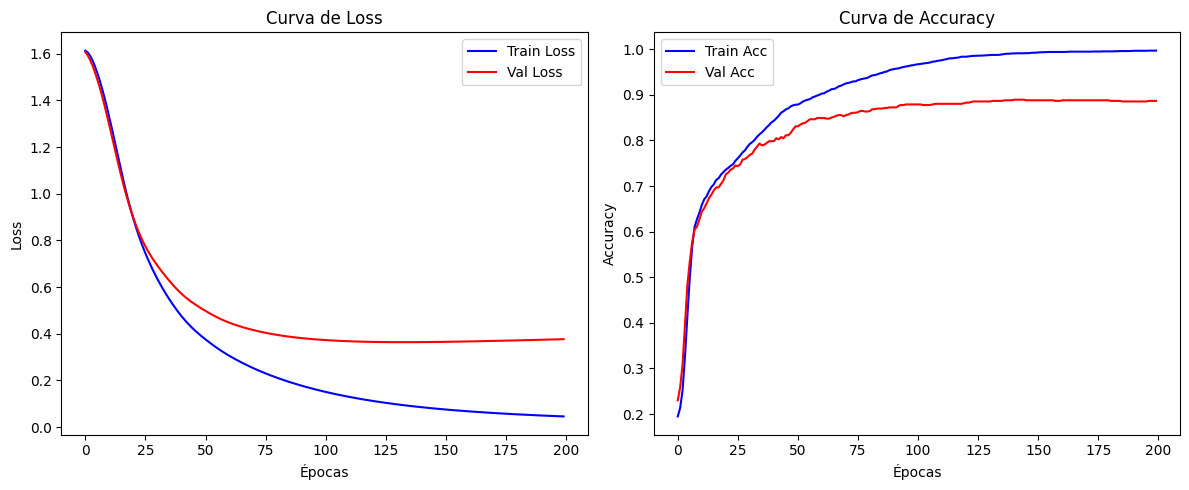


Relatório de Classificação Final:
              precision    recall  f1-score   support

   Anthropic       0.94      0.95      0.94       154
      Google       0.89      0.95      0.92       153
       Human       0.84      0.79      0.81       154
        Meta       0.90      0.88      0.89       154
      OpenAI       0.86      0.86      0.86       154

    accuracy                           0.89       769
   macro avg       0.89      0.89      0.89       769
weighted avg       0.89      0.89      0.89       769



In [20]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("A treinar o Modelo DNN Final...")

bow_final = NumpyBagOfWords(max_words=2500)
X_train_final = bow_final.fit_transform(X_train)
X_val_final = bow_final.transform(X_val)

model_final = NeuralNetwork()
model_final.add(DenseLayer(input_size=2500, output_size=164))
model_final.add(ReLUActivation())
model_final.add(DenseLayer(input_size=164, output_size=num_classes))
model_final.add(SoftmaxActivation())

model_final.compile(loss_func=CategoricalCrossEntropy(), optimizer=SGD(learning_rate=0.1))

history_final = model_final.fit(X_train_final, y_train_oh, epochs=200, val_data=(X_val_final, y_val_oh))

y_pred_final = np.argmax(model_final.forward(X_val_final, training=False), axis=1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_final['train_loss'], label='Train Loss', color='blue')
plt.plot(history_final['val_loss'], label='Val Loss', color='red')
plt.title('Curva de Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_final['train_acc'], label='Train Acc', color='blue')
plt.plot(history_final['val_acc'], label='Val Acc', color='red')
plt.title('Curva de Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

print("\nRelatório de Classificação Final:")
print(classification_report(y_val.values, y_pred_final, target_names=list(label_map.keys())))

model_final.save("../saved_models/DNN_final.pkl");
bow_final.save("../saved_models/DNN_bow_model.pkl")

In [ ]:
print("Melhor Val Accuracy DNN:", max(history_final['val_acc']))
print("Melhor Val Loss DNN:", min(history_final['val_loss']))

Melhor Val Accuracy DNN: 0.8894668400520156
Melhor Val Loss DNN: 0.36373121991168483


NameError: name 'X_sub' is not defined